Group B Exploration: Part 4

4. Resonance width vs. damping
   For different damping coefficients, measure the width of the resonance peak
   (FWHM) and check whether it follows the theoretical prediction Q = w0/Dw.

Simulating resonance curves …
     γ    Q_theory     Δω_meas      Q_meas   Q_err %
----------------------------------------------------
  0.05      10.000      0.1020       9.808     -1.92%
  0.10       5.000      0.2045       4.890     -2.20%
  0.20       2.500      0.4206       2.306     -7.75%
  0.30       1.667      0.6835       1.331    -20.11%
  0.50       1.000      0.7694       0.910     -9.02%


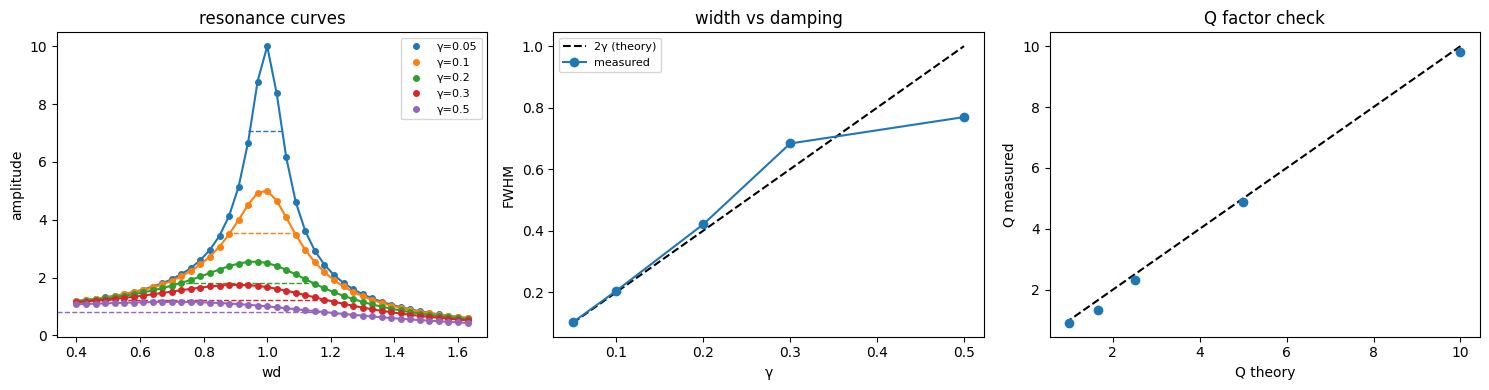

In [1]:
import numpy as np
import matplotlib.pyplot as plt

omega0 = 1.0
F_over_m = 1.0


def move_RK2(f, y, dt):
    ydot = f(y)
    y_half = y + ydot * dt / 2
    ydot_half = f(y_half)
    return y + ydot_half * dt


def make_diffeq(gamma, omega_d):
    def diffeq(y):
        x, v, t_now = y
        a = -2*gamma*v - omega0**2*x + F_over_m*np.cos(omega_d*t_now)
        return np.array([v, a, 1.0])
    return diffeq


def analytical_amplitude(gamma, omega_d):
    return F_over_m / np.sqrt((omega0**2 - omega_d**2)**2 + (2*gamma*omega_d)**2)


def simulate_amplitude(gamma, omega_d, t_total=250, dt=0.05):
    f = make_diffeq(gamma, omega_d)
    y = np.array([0.0, 0.0, 0.0])
    xs, ts = [], []
    for _ in np.arange(0, t_total, dt):
        xs.append(y[0])
        ts.append(y[2])
        y = move_RK2(f, y, dt)
    xs = np.array(xs)
    ts = np.array(ts)
    mask = ts > 0.80 * t_total
    return float(np.max(np.abs(xs[mask])))


def measure_fwhm(omega_d_vals, amplitudes):
    peak_idx = np.argmax(amplitudes)
    A_peak = amplitudes[peak_idx]
    omega_peak = omega_d_vals[peak_idx]
    half_max = A_peak / np.sqrt(2)

    left_idx = peak_idx
    while left_idx > 0 and amplitudes[left_idx] > half_max:
        left_idx -= 1
    if left_idx < peak_idx:
        w1 = np.interp(half_max,
                       [amplitudes[left_idx], amplitudes[left_idx + 1]],
                       [omega_d_vals[left_idx], omega_d_vals[left_idx + 1]])
    else:
        w1 = omega_d_vals[left_idx]

    right_idx = peak_idx
    while right_idx < len(amplitudes) - 1 and amplitudes[right_idx] > half_max:
        right_idx += 1
    if right_idx > peak_idx:
        w2 = np.interp(half_max,
                       [amplitudes[right_idx], amplitudes[right_idx - 1]],
                       [omega_d_vals[right_idx], omega_d_vals[right_idx - 1]])
    else:
        w2 = omega_d_vals[right_idx]

    return w2 - w1, omega_peak, half_max, w1, w2


gammas = [0.05, 0.10, 0.20, 0.30, 0.50]
omega_d_vals = np.arange(0.40, 1.65, 0.03)

print("Simulating resonance curves …")
print(f"{'γ':>6}  {'Q_theory':>10}  {'Δω_meas':>10}  {'Q_meas':>10}  {'Q_err %':>8}")
print("-" * 52)

results = {}

for gamma in gammas:
    amps_meas = np.array([simulate_amplitude(gamma, wd)
                         for wd in omega_d_vals])
    amps_anal = np.array([analytical_amplitude(gamma, wd)
                         for wd in omega_d_vals])

    fwhm, omega_peak, half_max, w1, w2 = measure_fwhm(omega_d_vals, amps_meas)

    Q_theory = omega0 / (2 * gamma)
    Q_meas = omega_peak / fwhm if fwhm > 0 else np.nan
    Q_err = 100 * (Q_meas - Q_theory) / Q_theory

    results[gamma] = dict(amps_meas=amps_meas, amps_anal=amps_anal,
                          fwhm=fwhm, omega_peak=omega_peak,
                          half_max=half_max, w1=w1, w2=w2,
                          Q_theory=Q_theory, Q_meas=Q_meas, Q_err=Q_err)

    print(f"{gamma:>6.2f}  {Q_theory:>10.3f}  {fwhm:>10.4f}  {Q_meas:>10.3f}  {Q_err:>+8.2f}%")

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

for gamma, color in zip(gammas, colors):
    r = results[gamma]
    ax1.plot(omega_d_vals, r['amps_meas'], 'o',
             color=color, markersize=4, label=f'γ={gamma}')
    ax1.plot(omega_d_vals, r['amps_anal'], '-', color=color)
    ax1.axhline(r['half_max'],
                xmin=(r['w1'] - omega_d_vals[0]) /
                (omega_d_vals[-1] - omega_d_vals[0]),
                xmax=(r['w2'] - omega_d_vals[0]) /
                (omega_d_vals[-1] - omega_d_vals[0]),
                color=color, lw=1, linestyle='--')

ax1.set_xlabel('wd')
ax1.set_ylabel('amplitude')
ax1.set_title('resonance curves')
ax1.legend(fontsize=8)

fwhm_meas = np.array([results[g]['fwhm'] for g in gammas])
fwhm_theory = 2 * np.array(gammas)

ax2.plot(gammas, fwhm_theory, 'k--', label='2γ (theory)')
ax2.plot(gammas, fwhm_meas, 'o-', color='tab:blue', label='measured')
ax2.set_xlabel('γ')
ax2.set_ylabel('FWHM')
ax2.set_title('width vs damping')
ax2.legend(fontsize=8)

Q_theory_vals = np.array([results[g]['Q_theory'] for g in gammas])
Q_meas_vals = np.array([results[g]['Q_meas'] for g in gammas])

ax3.plot(Q_theory_vals, Q_theory_vals, 'k--')
ax3.plot(Q_theory_vals, Q_meas_vals, 'o', color='tab:blue')
ax3.set_xlabel('Q theory')
ax3.set_ylabel('Q measured')
ax3.set_title('Q factor check')

plt.tight_layout()
plt.savefig('resonance_width_vs_damping.png', dpi=150, bbox_inches='tight')
plt.show()
